### Reference
- [업비트 레포지토리](https://github.com/sharebook-kr/pyupbit)
- [라이브러리](https://p444.tistory.com/entry/파이썬-라이브러리-만들기-배포)

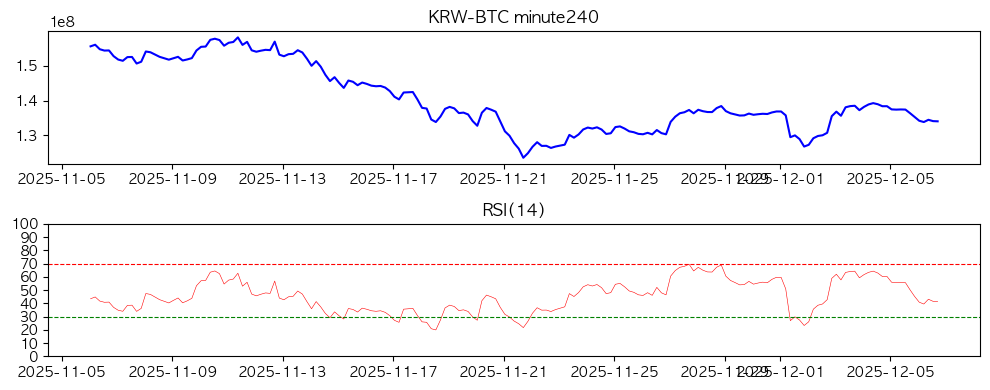

RSI 마지막: 41.25578042572626
df_clean 마지막 일자: 2025-12-06 17:00:00
===== 전체 RSI 출력 (시간순) =====
2025-11-06 01:00:00 43.404899610046655
2025-11-06 05:00:00 44.80026458601433
2025-11-06 09:00:00 41.687475816261
2025-11-06 13:00:00 40.77547002148572
2025-11-06 17:00:00 40.90926415601635
2025-11-06 21:00:00 36.92719681339939
2025-11-07 01:00:00 34.75251039801529
2025-11-07 05:00:00 33.97771135059901
2025-11-07 09:00:00 38.42547734296615
2025-11-07 13:00:00 38.59374964975779
2025-11-07 17:00:00 33.897470553245256
2025-11-07 21:00:00 36.16751287097437
2025-11-08 01:00:00 47.382423105146906
2025-11-08 05:00:00 46.71315901912148
2025-11-08 09:00:00 44.697821053357615
2025-11-08 13:00:00 42.73913342427116
2025-11-08 17:00:00 41.52488996995045
2025-11-08 21:00:00 40.27435503692594
2025-11-09 01:00:00 42.21692965129625
2025-11-09 05:00:00 44.029780905683815
2025-11-09 09:00:00 40.37474341286079
2025-11-09 13:00:00 41.86528505708043
2025-11-09 17:00:00 43.7749042591345
2025-11-09 21:00:00 53.264843244

In [ ]:
import datetime
import lib.upbit_wrapper as uw
import matplotlib.pyplot as plt

# 시뮬레이션 세팅
COIN     = "KRW-BTC"                        # 코인
INTERVAL = "minute240"                      # 분봉
START    = datetime.datetime(2025, 11, 6)   # 시작일    
END      = datetime.datetime(2025, 12, 6 + 1)   # 종료일
RSI14    = 14                               # RSI

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'  # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False   # 음수(-) 폰트 깨짐 방지

# 그래프 2행 1열로 보이기 위함
fig, ax = plt.subplots(2, 1, figsize=(10, 4))


# df_clean → START~END (그래프 표시용)
# df_full  → buffer 포함 (RSI 계산용 내부 전용)
df_clean, df_full = uw.get_ohlcv_range(COIN, START, END, interval=INTERVAL)

# ---------- 위쪽 그래프 ----------
ax[0].plot(df_clean['close'], color='blue')
ax[0].set_title(f"{COIN} {INTERVAL}")

# ---------- 아래쪽 그래프 (RSI14) ----------
# RSI 전체 계산
rsi_full = uw.compute_rsi(df_full['close'], RSI14)

# START 이후만 보여줘야 정확
rsi_clean = rsi_full[rsi_full.index >= START]

ax[1].plot(rsi_clean, color='red', linewidth=0.4)
ax[1].axhline(70, color='red', linestyle="--", linewidth=0.8)
ax[1].axhline(30, color='green', linestyle="--", linewidth=0.8)
ax[1].set_yticks(range(0, 101, 10))
ax[1].set_title("RSI(14)")

plt.tight_layout()
plt.show()
# print(df_clean.tail())
print("RSI 마지막:", rsi_clean.iloc[-1])
print("df_clean 마지막 일자:", df_clean.index[-1])



# 🔥 전체 RSI 출력
print("===== 전체 RSI 출력 (시간순) =====")
for ts, value in rsi_clean.items():
    print(ts, value)

print("\n===== 마지막 5개의 RSI =====")
print(rsi_clean.tail())

print("\n===== df_clean 마지막 봉 =====")
print(df_clean.tail())